# 04 — Train Proposed Method (LoRA + FAISS-Grouped Mini-Batches)

**Goal:** Train the same model/dataset/hyperparams as the baseline, but with **semantic grouped batching**.

**Key idea:** We keep the *same* train/eval split and tokenization, but we override the Trainer's train DataLoader
to yield batches constructed from FAISS neighbors (restricted to the train split).

**Outputs saved to Drive (per run):**
- `run_manifest.json` (full config snapshot)
- `logs/metrics.jsonl` (Trainer logs)
- `adapter/` (LoRA adapter)
- `plots/loss_curve.png`
- `run_summary.json`
- appended row to `runs/experiment_logs/experiment_logs.csv`


In [1]:
# --- 0) Mount Drive ---
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [2]:
!pip install -q faiss-cpu sentence-transformers datasets tqdm  # faiss-gpu/faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 108.1 MB/s eta 0:00:00


In [3]:
# --- 1) Imports ---
import os
import json
import time
import math
import random
from dataclasses import dataclass
from typing import Dict, Any, List, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader

import faiss
from datasets import load_from_disk
from transformers import (
    AutoTokenizer,
    AutoModelForSeq2SeqLM,
    DataCollatorForSeq2Seq,
    Seq2SeqTrainer,
    Seq2SeqTrainingArguments,
    TrainerCallback,
)
from peft import LoraConfig, get_peft_model, TaskType


In [4]:
# --- 2) Load bootstrap manifest (paths) ---
ROOT = '/content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research'
MANIFEST_PATH = f'{ROOT}/manifests/bootstrap_manifest.json'

if not os.path.exists(MANIFEST_PATH):
    raise FileNotFoundError(
        f'bootstrap_manifest.json not found at: {MANIFEST_PATH}\n'
        'Run 00_bootstrap_downloads.ipynb first.'
    )

with open(MANIFEST_PATH, 'r', encoding='utf-8') as f:
    manifest = json.load(f)

DIRS = manifest['dirs']

def _safe_makedirs(p: str):
    os.makedirs(p, exist_ok=True)

def _now_utc() -> str:
    return time.strftime('%Y-%m-%dT%H:%M:%SZ', time.gmtime())

print('Loaded manifest created_at_utc:', manifest.get('created_at_utc'))
print('ROOT:', manifest.get('root', ROOT))


Loaded manifest created_at_utc: 2026-03-26T00:00:00Z
ROOT: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research


## Config
Keep these identical to your baseline where applicable.

Important additions:
- `BUNDLE_NAME` must match Notebook 01/02 output
- `TOP_K` should be >= `PER_DEVICE_BATCH`


In [5]:
# ---------- Experiment identity ----------
EXP_ID = 'exp_004_grouped_lora'
METHOD = 'grouped_lora'

# ---------- Dataset ----------
DATASET_NAME = 'dolly_small_1k'   # scale later
SPLIT_NAME = 'train'

INSTRUCTION_FIELD = 'instruction'
CONTEXT_FIELD = 'context'
RESPONSE_FIELD = 'response'

# ---------- Model ----------
BASE_MODEL_DIRNAME = 'flan-t5-small'
BASE_MODEL_PATH = f"{DIRS['shared_models_base']}/{BASE_MODEL_DIRNAME}"

# ---------- Tokenization ----------
MAX_SOURCE_LEN = 256
MAX_TARGET_LEN = 256

# ---------- Train/Eval split ----------
EVAL_RATIO = 0.1
SEED = 42

# ---------- Training ----------
EPOCHS = 20
PER_DEVICE_BATCH = 8
GRAD_ACCUM = 1
LEARNING_RATE = 5e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.03

LOGGING_STEPS = 20
EVAL_STRATEGY = 'steps'
EVAL_STEPS = 100
SAVE_STEPS = 100
SAVE_TOTAL_LIMIT = 3

# ---------- LoRA ----------
LORA_R = 16
LORA_ALPHA = 32
LORA_DROPOUT = 0.05
TARGET_MODULES = ['q', 'v']

# ---------- Grouping / Retrieval ----------
EMBED_MODEL_DIRNAME = 'all-MiniLM-L6-v2'
BUNDLE_NAME = f"{DATASET_NAME}__{EMBED_MODEL_DIRNAME}"
TOP_K = 32  # should match neighbors_topk_idx.npy in bundle

# ---------- Caching ----------
CACHE_TOKENIZED = True

# ---------- Precision ----------
FP16 = False
BF16 = False

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('DEVICE:', DEVICE)
print('BASE_MODEL_PATH:', BASE_MODEL_PATH)
print('BUNDLE_NAME:', BUNDLE_NAME)


DEVICE: cuda
BASE_MODEL_PATH: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/shared/models/base_models/flan-t5-small
BUNDLE_NAME: dolly_small_1k__all-MiniLM-L6-v2


In [ ]:
# --- 3) Output directories ---
RUN_ROOT = f"{DIRS['experiments']}/{EXP_ID}"
OUT_CHECKPOINTS = f"{RUN_ROOT}/checkpoints"
OUT_LOGS = f"{RUN_ROOT}/logs"
OUT_PLOTS = f"{RUN_ROOT}/plots"
OUT_TABLES = f"{RUN_ROOT}/tables"

for p in [RUN_ROOT, OUT_CHECKPOINTS, OUT_LOGS, OUT_PLOTS, OUT_TABLES]:
    _safe_makedirs(p)

RUN_MANIFEST_PATH = f"{RUN_ROOT}/run_manifest.json"
RUN_SUMMARY_PATH = f"{RUN_ROOT}/run_summary.json"
METRICS_JSONL_PATH = f"{OUT_LOGS}/metrics.jsonl"
LOSS_PLOT_PATH = f"{OUT_PLOTS}/loss_curve.png"

EXPERIMENT_CSV_PATH = f"{DIRS['experiments']}/experiment_logs/experiment_logs.csv"
_safe_makedirs(os.path.dirname(EXPERIMENT_CSV_PATH))

print('RUN_ROOT:', RUN_ROOT)
print('EXPERIMENT_CSV_PATH:', EXPERIMENT_CSV_PATH)


RUN_ROOT: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/runs/exp_004_grouped_lora
EXPERIMENT_CSV_PATH: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/runs/experiment_logs/experiment_logs.csv


In [ ]:
# --- 4) Determinism ---
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)


## Load dataset + keep raw indices
Critical: FAISS neighbors are computed over the **raw dataset order** (Notebook 01).
So we attach `raw_idx` to each row BEFORE shuffling/splitting.


In [ ]:
# --- 5) Load dataset and attach raw_idx ---
dataset_path = f"{DIRS['shared_datasets_raw']}/{DATASET_NAME}"
if not os.path.exists(dataset_path):
    raise FileNotFoundError(f'Dataset not found: {dataset_path}')

ds = load_from_disk(dataset_path)
raw = ds[SPLIT_NAME]

required = {INSTRUCTION_FIELD, RESPONSE_FIELD}
missing = [c for c in required if c not in raw.column_names]
if missing:
    raise KeyError(f"Missing columns in dataset: {missing}. Available: {raw.column_names}")

# add raw_idx
raw = raw.map(lambda ex, idx: {'raw_idx': int(idx)}, with_indices=True)

# shuffle then split deterministically (same policy as baseline)
base = raw.shuffle(seed=SEED)
n = len(base)
n_eval = max(1, int(n * EVAL_RATIO))
eval_ds = base.select(range(n_eval))
train_ds = base.select(range(n_eval, n))

def keep_example(ex):
    r = ex.get(RESPONSE_FIELD)
    i = ex.get(INSTRUCTION_FIELD)
    return (r is not None and str(r).strip() != '') and (i is not None and str(i).strip() != '')

train_ds = train_ds.filter(keep_example)
eval_ds = eval_ds.filter(keep_example)

print('Rows total:', n)
print('Train:', len(train_ds), 'Eval:', len(eval_ds))
print('Example raw_idx:', train_ds[0]['raw_idx'])
print('Example instruction:', train_ds[0][INSTRUCTION_FIELD])


Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/900 [00:00<?, ? examples/s]

Filter:   0%|          | 0/100 [00:00<?, ? examples/s]

Rows total: 1000
Train: 900 Eval: 100
Example raw_idx: 797
Example instruction: Which is a species of fish? Cisco or Palo Alto


## Load model + apply LoRA
Identical to baseline.


In [ ]:
# --- 6) Load tokenizer/model ---
if not os.path.exists(BASE_MODEL_PATH):
    raise FileNotFoundError(f'Base model not found in Drive: {BASE_MODEL_PATH}')

tokenizer = AutoTokenizer.from_pretrained(BASE_MODEL_PATH)
base_model = AutoModelForSeq2SeqLM.from_pretrained(BASE_MODEL_PATH)
base_model.to(DEVICE)

lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_2_SEQ_LM,
    r=LORA_R,
    lora_alpha=LORA_ALPHA,
    lora_dropout=LORA_DROPOUT,
    bias='none',
    target_modules=TARGET_MODULES,
)

model = get_peft_model(base_model, lora_cfg)
model.print_trainable_parameters()


Loading weights:   0%|          | 0/190 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


trainable params: 688,128 || all params: 77,649,280 || trainable%: 0.8862


## Tokenization (cached)
Important: keep `raw_idx` so we can map FAISS neighbors into the train split.


In [ ]:
# --- 7) Prompt builder + tokenization ---
def build_prompt(example: Dict[str, Any]) -> str:
    instr = (example.get(INSTRUCTION_FIELD) or '').strip()
    ctx = (example.get(CONTEXT_FIELD) or '').strip()
    if ctx:
        return f"### Instruction:\n{instr}\n\n### Context:\n{ctx}\n\n### Response:\n"
    return f"### Instruction:\n{instr}\n\n### Response:\n"

def preprocess_batch(batch: Dict[str, List[Any]]) -> Dict[str, Any]:
    prompts = []
    targets = []
    raw_idxs = []

    # batch contains columns as lists
    for instr, ctx, resp, ridx in zip(
        batch.get(INSTRUCTION_FIELD, []),
        batch.get(CONTEXT_FIELD, [''] * len(batch[INSTRUCTION_FIELD])),
        batch.get(RESPONSE_FIELD, []),
        batch.get('raw_idx', []),
    ):
        ex = {
            INSTRUCTION_FIELD: instr,
            CONTEXT_FIELD: ctx,
            RESPONSE_FIELD: resp,
        }
        prompts.append(build_prompt(ex))
        targets.append((resp or '').strip())
        raw_idxs.append(int(ridx))

    model_inputs = tokenizer(
        prompts,
        max_length=MAX_SOURCE_LEN,
        truncation=True,
        padding=False,
    )

    labels = tokenizer(
        text_target=targets,
        max_length=MAX_TARGET_LEN,
        truncation=True,
        padding=False,
    )
    model_inputs['labels'] = labels['input_ids']
    model_inputs['raw_idx'] = raw_idxs
    return model_inputs


In [ ]:
# --- 8) Tokenize train/eval (load cached if available) ---
token_cache_dir = f"{DIRS['datasets_processed']}/{DATASET_NAME}__{BASE_MODEL_DIRNAME}__tok_with_rawidx_v1"
train_tok_path = f"{token_cache_dir}/train"
eval_tok_path = f"{token_cache_dir}/eval"

if CACHE_TOKENIZED and os.path.exists(train_tok_path) and os.path.exists(eval_tok_path):
    train_tok = load_from_disk(train_tok_path)
    eval_tok = load_from_disk(eval_tok_path)
    print('Loaded cached tokenized datasets from:', token_cache_dir)
else:
    train_tok = train_ds.map(
        preprocess_batch,
        batched=True,
        remove_columns=train_ds.column_names,  # raw text columns removed, but we keep raw_idx via preprocess
        desc='Tokenizing train',
    )
    eval_tok = eval_ds.map(
        preprocess_batch,
        batched=True,
        remove_columns=eval_ds.column_names,
        desc='Tokenizing eval',
    )

    if CACHE_TOKENIZED:
        _safe_makedirs(train_tok_path)
        _safe_makedirs(eval_tok_path)
        train_tok.save_to_disk(train_tok_path)
        eval_tok.save_to_disk(eval_tok_path)
        print('Saved tokenized datasets to:', token_cache_dir)

print('Tokenized keys:', train_tok.column_names)
print('raw_idx example:', train_tok[0]['raw_idx'])


Tokenizing train:   0%|          | 0/900 [00:00<?, ? examples/s]

Tokenizing eval:   0%|          | 0/100 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/900 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/100 [00:00<?, ? examples/s]

Saved tokenized datasets to: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/datasets/processed/dolly_small_1k__flan-t5-small__tok_with_rawidx_v1
Tokenized keys: ['raw_idx', 'input_ids', 'attention_mask', 'labels']
raw_idx example: 797


In [ ]:
# --- 9) Data collator ---
data_collator = DataCollatorForSeq2Seq(
    tokenizer=tokenizer,
    model=model,
    padding='longest',
)


## Load FAISS bundle + neighbor arrays
We'll map FAISS neighbors (raw indices) into **train_tok positions only**.


In [ ]:
# --- 10) Load bundle + neighbors ---
bundle_dir = f"{DIRS['indexes']}/{BUNDLE_NAME}"
emb_path = f"{bundle_dir}/embeddings.npy"
faiss_index_path = f"{bundle_dir}/faiss.index"
neighbors_idx_path = f"{bundle_dir}/neighbors_topk_idx.npy"
neighbors_score_path = f"{bundle_dir}/neighbors_topk_scores.npy"

for p in [bundle_dir, emb_path, faiss_index_path, neighbors_idx_path, neighbors_score_path]:
    if not os.path.exists(p):
        raise FileNotFoundError(
            f"Missing {p}. Make sure you ran 01_build_embeddings_faiss.ipynb and 02_grouped_minibatches.ipynb."
        )

X = np.load(emb_path).astype('float32')
index = faiss.read_index(faiss_index_path)
neighbors_idx = np.load(neighbors_idx_path)
neighbors_score = np.load(neighbors_score_path)

print('Embeddings:', X.shape)
print('Neighbors idx:', neighbors_idx.shape)
print('FAISS ntotal:', index.ntotal)


Embeddings: (1000, 384)
Neighbors idx: (1000, 32)
FAISS ntotal: 1000


## Build train mapping: raw_idx -> train position
FAISS neighbors are in raw_idx space; Trainer sees train examples in train_tok index space.


In [ ]:
# --- 11) raw_idx -> train_pos mapping ---
train_raw_idxs = train_tok['raw_idx']
raw_to_trainpos = {int(ridx): int(pos) for pos, ridx in enumerate(train_raw_idxs)}
trainpos_to_raw = [int(ridx) for ridx in train_raw_idxs]

print('Train mapping size:', len(raw_to_trainpos))
print('Example: train_pos=0 -> raw_idx', trainpos_to_raw[0])


Train mapping size: 900
Example: train_pos=0 -> raw_idx 797


## Grouped Batch Sampler (trainpos batches)
Batch construction:
- shuffle anchors in **train positions** (deterministic)
- for each anchor, use its raw_idx neighbor list
- include only neighbors present in train split
- avoid duplicates within batch and across batches

We also compute a simple **batch coherence** metric: mean anchor→member similarity.


In [ ]:
@dataclass
class GroupedSamplerConfig:
    batch_size: int
    seed: int
    drop_last: bool = True

class GroupedTrainBatchSampler:
    def __init__(
        self,
        trainpos_to_raw: List[int],
        raw_to_trainpos: Dict[int, int],
        neighbors_idx: np.ndarray,
        neighbors_score: np.ndarray,
        cfg: GroupedSamplerConfig,
    ):
        self.trainpos_to_raw = trainpos_to_raw
        self.raw_to_trainpos = raw_to_trainpos
        self.neighbors_idx = neighbors_idx
        self.neighbors_score = neighbors_score
        self.cfg = cfg
        self.n = len(trainpos_to_raw)

    def __iter__(self):
        rng = random.Random(self.cfg.seed)
        anchors = list(range(self.n))
        rng.shuffle(anchors)

        used_global = set()

        for a_pos in anchors:
            if a_pos in used_global:
                continue

            a_raw = self.trainpos_to_raw[a_pos]
            batch = [a_pos]
            used_in_batch = {a_pos}

            # iterate neighbors of anchor (raw space)
            for nb_raw in self.neighbors_idx[a_raw]:
                if len(batch) >= self.cfg.batch_size:
                    break
                nb_raw = int(nb_raw)
                nb_pos = self.raw_to_trainpos.get(nb_raw)
                if nb_pos is None:
                    continue
                if nb_pos in used_in_batch:
                    continue
                if nb_pos in used_global:
                    continue
                batch.append(nb_pos)
                used_in_batch.add(nb_pos)

            if len(batch) == self.cfg.batch_size:
                for p in batch:
                    used_global.add(p)
                yield batch
            else:
                if not self.cfg.drop_last and len(batch) > 0:
                    for p in batch:
                        used_global.add(p)
                    yield batch

    def __len__(self):
        # conservative estimate; exact length depends on duplicates/coverage
        return self.n // self.cfg.batch_size

def compute_coherence_for_batch(batch_trainpos: List[int]) -> float:
    # mean similarity from anchor raw to each member raw (including itself)
    a_pos = batch_trainpos[0]
    a_raw = trainpos_to_raw[a_pos]
    sims = []
    for p in batch_trainpos:
        r = trainpos_to_raw[p]
        # find r inside neighbor list of a_raw; if not found, approx with dot from embeddings
        # (should be found for most members)
        # fast fallback:
        sims.append(float(np.dot(X[a_raw], X[r])))
    return float(sum(sims) / len(sims))


In [ ]:
# --- 12) Quick sampler sanity check ---
sampler_cfg = GroupedSamplerConfig(batch_size=PER_DEVICE_BATCH, seed=SEED, drop_last=True)
batch_sampler = GroupedTrainBatchSampler(
    trainpos_to_raw=trainpos_to_raw,
    raw_to_trainpos=raw_to_trainpos,
    neighbors_idx=neighbors_idx,
    neighbors_score=neighbors_score,
    cfg=sampler_cfg,
)

first_batches = []
for i, b in enumerate(batch_sampler):
    first_batches.append(b)
    if i >= 2:
        break

print('Example grouped batches (train positions):', first_batches)
print('Coherence:', [compute_coherence_for_batch(b) for b in first_batches])


Example grouped batches (train positions): [[92, 723, 487, 801, 148, 195, 721, 894], [877, 236, 88, 434, 586, 367, 580, 321], [443, 8, 201, 793, 861, 867, 420, 117]]
Coherence: [0.43777020648121834, 0.33897859044373035, 0.5046478770673275]


## JSONL metrics logger callback
Same as baseline.


In [ ]:
class JsonlLoggerCallback(TrainerCallback):
    def __init__(self, path: str):
        self.path = path
        with open(self.path, 'w', encoding='utf-8') as f:
            f.write('')

    def on_log(self, args, state, control, logs=None, **kwargs):
        if not logs:
            return
        row = {
            'utc': _now_utc(),
            'step': int(state.global_step),
            'epoch': float(state.epoch) if state.epoch is not None else None,
            **{k: float(v) if isinstance(v, (int, float, np.number)) else v for k, v in logs.items()},
        }
        with open(self.path, 'a', encoding='utf-8') as f:
            f.write(json.dumps(row) + '\n')


## Custom Trainer to inject grouped DataLoader
We override `get_train_dataloader()` so the Trainer trains on our grouped batches.


In [ ]:
class GroupedSeq2SeqTrainer(Seq2SeqTrainer):
    def __init__(self, *args, grouped_batch_sampler=None, **kwargs):
        super().__init__(*args, **kwargs)
        self._grouped_batch_sampler = grouped_batch_sampler

    def get_train_dataloader(self):
        if self.train_dataset is None:
            raise ValueError('Trainer: training requires a train_dataset.')
        if self._grouped_batch_sampler is None:
            return super().get_train_dataloader()

        return DataLoader(
            self.train_dataset,
            batch_sampler=self._grouped_batch_sampler,
            collate_fn=self.data_collator,
            num_workers=0,
            pin_memory=torch.cuda.is_available(),
        )


In [ ]:
# --- 13) Warmup steps + TrainingArguments (match baseline) ---
effective_train_bs = PER_DEVICE_BATCH * GRAD_ACCUM
steps_per_epoch = max(1, len(train_tok) // effective_train_bs)
total_train_steps = steps_per_epoch * EPOCHS
warmup_steps = int(WARMUP_RATIO * total_train_steps)

training_args = Seq2SeqTrainingArguments(
    output_dir=OUT_CHECKPOINTS,
    num_train_epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
    warmup_steps=warmup_steps,

    per_device_train_batch_size=PER_DEVICE_BATCH,
    per_device_eval_batch_size=PER_DEVICE_BATCH,
    gradient_accumulation_steps=GRAD_ACCUM,

    eval_strategy=EVAL_STRATEGY,
    eval_steps=EVAL_STEPS,
    save_steps=SAVE_STEPS,
    save_total_limit=SAVE_TOTAL_LIMIT,

    logging_steps=LOGGING_STEPS,
    report_to='none',

    dataloader_drop_last=True,

    fp16=FP16,
    bf16=BF16,

    load_best_model_at_end=True,
    metric_for_best_model='eval_loss',
    greater_is_better=False,

    predict_with_generate=False,
)


In [ ]:
# --- 14) Save run manifest ---
run_manifest = {
    'exp_id': EXP_ID,
    'method': METHOD,
    'created_at_utc': _now_utc(),
    'dataset_name': DATASET_NAME,
    'base_model': BASE_MODEL_DIRNAME,
    'seed': SEED,
    'train_size': len(train_tok),
    'eval_size': len(eval_tok),
    'bundle_name': BUNDLE_NAME,
    'hparams': {
        'epochs': EPOCHS,
        'per_device_batch': PER_DEVICE_BATCH,
        'grad_accum': GRAD_ACCUM,
        'lr': LEARNING_RATE,
        'weight_decay': WEIGHT_DECAY,
        'warmup_ratio': WARMUP_RATIO,
        'warmup_steps': warmup_steps,
        'max_source_len': MAX_SOURCE_LEN,
        'max_target_len': MAX_TARGET_LEN,
    },
    'lora': {
        'r': LORA_R,
        'alpha': LORA_ALPHA,
        'dropout': LORA_DROPOUT,
        'target_modules': TARGET_MODULES,
    },
    'grouping': {
        'top_k': TOP_K,
        'batch_size': PER_DEVICE_BATCH,
        'sampler_seed': SEED,
        'bundle_dir': bundle_dir,
    },
}

with open(RUN_MANIFEST_PATH, 'w', encoding='utf-8') as f:
    json.dump(run_manifest, f, indent=2)

print('Wrote:', RUN_MANIFEST_PATH)


Wrote: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/runs/exp_004_grouped_lora/run_manifest.json


In [ ]:
# --- 15) Trainer (Grouped) ---
trainer = GroupedSeq2SeqTrainer(
    model=model,
    args=training_args,
    train_dataset=train_tok,
    eval_dataset=eval_tok,
    data_collator=data_collator,
    callbacks=[JsonlLoggerCallback(METRICS_JSONL_PATH)],
    grouped_batch_sampler=batch_sampler,
)


## Train + Evaluate


In [ ]:
train_result = trainer.train()
eval_result = trainer.evaluate()

print('Train result:', train_result)
print('Eval result:', eval_result)


Step,Training Loss,Validation Loss
100,9.669920,9.582687
200,9.411784,9.270412
300,9.239950,9.068267
400,9.162122,8.964711
500,9.097620,8.877770
600,9.038209,8.822173
700,8.995272,8.781294
800,8.961004,8.741277
900,8.936263,8.698956
1000,8.909725,8.678803


Train result: TrainOutput(global_step=1980, training_loss=9.01236458980676, metrics={'train_runtime': 254.6729, 'train_samples_per_second': 70.679, 'train_steps_per_second': 8.796, 'total_flos': 1146063278899200.0, 'train_loss': 9.01236458980676, 'epoch': 19.883928571428573})
Eval result: {'eval_loss': 8.559309959411621, 'eval_runtime': 0.591, 'eval_samples_per_second': 169.214, 'eval_steps_per_second': 21.998, 'epoch': 19.883928571428573}


## Save adapter + plot loss


In [ ]:
# --- 16) Save adapter ---
adapter_out = f"{RUN_ROOT}/adapter"
_safe_makedirs(adapter_out)
trainer.model.save_pretrained(adapter_out)
tokenizer.save_pretrained(adapter_out)

print('Saved adapter to:', adapter_out)


Saved adapter to: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/runs/exp_004_grouped_lora/adapter


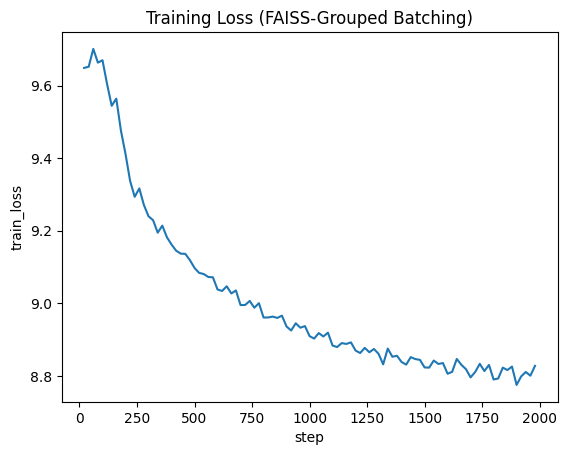

Saved: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/runs/exp_004_grouped_lora/plots/loss_curve.png


In [ ]:
# --- 17) Plot loss curve from metrics.jsonl ---
rows = []
with open(METRICS_JSONL_PATH, 'r', encoding='utf-8') as f:
    for line in f:
        line = line.strip()
        if line:
            rows.append(json.loads(line))

df = pd.DataFrame(rows)
loss_df = df[df.get('loss').notna()] if 'loss' in df.columns else pd.DataFrame()

plt.figure()
if not loss_df.empty:
    plt.plot(loss_df['step'], loss_df['loss'])
    plt.xlabel('step')
    plt.ylabel('train_loss')
    plt.title('Training Loss (FAISS-Grouped Batching)')
else:
    plt.text(0.5, 0.5, 'No loss events found', ha='center')

plt.savefig(LOSS_PLOT_PATH, dpi=180, bbox_inches='tight')
plt.show()
print('Saved:', LOSS_PLOT_PATH)


## Compute batch coherence stats (optional but useful)
We compute mean anchor→member cosine similarity for a sample of batches.
This is a concrete artifact to justify that grouped batches are actually semantically coherent.


In [ ]:
# --- 18) Coherence stats over sampled batches ---
cohs = []
for i, b in enumerate(batch_sampler):
    cohs.append(compute_coherence_for_batch(b))
    if i >= 500:  # sample up to 501 batches
        break

coh_mean = float(np.mean(cohs)) if cohs else None
coh_std = float(np.std(cohs)) if cohs else None
print('Coherence mean:', coh_mean, 'std:', coh_std, 'n_batches_sampled:', len(cohs))


Coherence mean: 0.4174168688442671 std: 0.08387182839053646 n_batches_sampled: 99


## Run summary + append to experiment_logs.csv


In [ ]:
# --- 19) Save run summary + append CSV ---
train_loss_last = None
if 'loss' in df.columns:
    tmp = df[df['loss'].notna()]
    if len(tmp) > 0:
        train_loss_last = float(tmp.iloc[-1]['loss'])

final_summary = {
    'exp_id': EXP_ID,
    'method': METHOD,
    'completed_at_utc': _now_utc(),
    'dataset_name': DATASET_NAME,
    'base_model': BASE_MODEL_DIRNAME,
    'seed': SEED,
    'train_size': len(train_tok),
    'eval_size': len(eval_tok),
    'final_train_loss_last': train_loss_last,
    'final_eval_metrics': eval_result,
    'coherence': {
        'mean_anchor_member_cosine': coh_mean,
        'std_anchor_member_cosine': coh_std,
        'sampled_batches': len(cohs),
    },
    'paths': {
        'run_root': RUN_ROOT,
        'adapter': adapter_out,
        'metrics_jsonl': METRICS_JSONL_PATH,
        'loss_plot': LOSS_PLOT_PATH,
        'run_manifest': RUN_MANIFEST_PATH,
    }
}

with open(RUN_SUMMARY_PATH, 'w', encoding='utf-8') as f:
    json.dump(final_summary, f, indent=2)

print('Wrote summary:', RUN_SUMMARY_PATH)

# Append to experiment_logs.csv
row = {
    'exp_id': EXP_ID,
    'date_utc': final_summary['completed_at_utc'],
    'model': BASE_MODEL_DIRNAME,
    'dataset': DATASET_NAME,
    'method': METHOD,
    'batch_size': PER_DEVICE_BATCH,
    'grad_accum': GRAD_ACCUM,
    'lr': LEARNING_RATE,
    'epochs': EPOCHS,
    'seed': SEED,
    'train_loss_last': train_loss_last,
    'eval_loss': float(eval_result['eval_loss']) if 'eval_loss' in eval_result else None,
    'coh_mean': coh_mean,
    'coh_std': coh_std,
    'adapter_path': adapter_out,
    'run_root': RUN_ROOT,
    'notes': 'FAISS grouped batching LoRA',
}

if os.path.exists(EXPERIMENT_CSV_PATH):
    df_csv = pd.read_csv(EXPERIMENT_CSV_PATH)
    df_csv = pd.concat([df_csv, pd.DataFrame([row])], ignore_index=True)
else:
    df_csv = pd.DataFrame([row])

df_csv.to_csv(EXPERIMENT_CSV_PATH, index=False)
print('Updated:', EXPERIMENT_CSV_PATH)

df_csv.tail(5)


Wrote summary: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/runs/exp_004_grouped_lora/run_summary.json
Updated: /content/drive/MyDrive/Compass_AI_ML_Research/llm-batching-research/runs/experiment_logs/experiment_logs.csv


,exp_id,date_utc,model,dataset,method,batch_size,grad_accum,lr,epochs,seed,train_loss,eval_loss,adapter_path,run_root,notes,train_loss_last,coh_mean,coh_std
0,exp_003_baseline_random_lora,2026-03-05T18:11:41Z,flan-t5-small,dolly_small_1k,random_lora,8,1,0.00005,3,42,NaN,NaN,/content/drive/MyDrive/Compass_AI_ML_Research/...,/content/drive/MyDrive/Compass_AI_ML_Research/...,baseline random batching LoRA,NaN,NaN,NaN
1,exp_003_baseline_random_lora,2026-03-05T18:27:24Z,flan-t5-small,dolly_small_1k,random_lora,8,1,0.00005,20,42,8.55408,8.55408,/content/drive/MyDrive/Compass_AI_ML_Research/...,/content/drive/MyDrive/Compass_AI_ML_Research/...,baseline random batching LoRA,NaN,NaN,NaN
2,exp_004_grouped_lora,2026-03-05T19:25:00Z,flan-t5-small,dolly_small_1k,grouped_lora,8,1,0.00005,20,42,NaN,8.55931,/content/drive/MyDrive/Compass_AI_ML_Research/...,/content/drive/MyDrive/Compass_AI_ML_Research/...,FAISS grouped batching LoRA,8.827762,0.417417,0.083872
